## Named Entity Recognition

In [2]:
import nltk
from collections import Counter
from nltk import ne_chunk, pos_tag, sent_tokenize, word_tokenize
from nltk.corpus import ieer

In [3]:
# Pick any one IEER document (no search for best passage)
file_id = ieer.fileids()[0]
text = ieer.raw(file_id)

# Use a small passage from that document
sentences = sent_tokenize(text)
passage = " ".join(sentences[:8]) if len(sentences) >= 8 else text

print(f"IEER file: {file_id}")
print("\nPASSAGE:\n")
print(passage)

IEER file: APW_19980314

PASSAGE:

<IEER_DOC type="NEWSWIRE" fileid="" collect_date="" collect_src="" src_lang="" content_lang="" proc_remarks="IEER document translation">
<DOC>
<DOCNO> APW19980314.0391 </DOCNO>
<DOCTYPE> NEWS STORY </DOCTYPE>
<DATE_TIME> 03/14/1998 10:36:00 </DATE_TIME>
<BODY>
<HEADLINE>
Kenyans protest tax hikes
</HEADLINE>
<TEXT>
	   <b_enamex type="LOCATION">NAIROBI<e_enamex>, <b_enamex type="LOCATION">Kenya<e_enamex> (<b_enamex type="ORGANIZATION">AP<e_enamex>) _ <b_numex type="CARDINAL">Thousands<e_numex> of laborers, students and
opposition politicians on <b_timex type="DATE">Saturday<e_timex> protested tax hikes imposed by
their cash-strapped government, which they accused of failing to
provide basic services. Beneath a scorching sun, they sang anti-government songs and
chanted ``<b_enamex type="PERSON">Moi<e_enamex> must go,'' showing their derision for President
<b_enamex type="PERSON">Daniel arap Moi<e_enamex>, <b_enamex type="LOCATION">Kenya<e_enamex>'s rul

In [4]:
# 2) Run NER
tokens = word_tokenize(passage)
tagged_tokens = pos_tag(tokens)
ner_tree = ne_chunk(tagged_tokens, binary=False)


In [5]:
# 3) Explore different NER tags and extracted entities
entities = []
for chunk in ner_tree:
    if hasattr(chunk, "label"):
        label = chunk.label()
        entity_text = " ".join(word for word, _ in chunk.leaves())
        entities.append((entity_text, label))

label_counts = Counter(label for _, label in entities)

print("\n\nEXTRACTED ENTITIES:")
for entity_text, label in entities:
    print(f"- {entity_text:<35} -> {label}")

print("\nTAGS FOUND (and counts):")
for label, count in sorted(label_counts.items()):
    print(f"- {label}: {count}")



EXTRACTED ENTITIES:
- IEER_DOC                            -> ORGANIZATION
- NEWSWIRE                            -> ORGANIZATION
- IEER                                -> ORGANIZATION
- LOCATION                            -> ORGANIZATION
- NAIROBI                             -> ORGANIZATION
- LOCATION                            -> ORGANIZATION
- Kenya                               -> PERSON
- ORGANIZATION                        -> ORGANIZATION
- AP                                  -> ORGANIZATION
- CARDINAL                            -> ORGANIZATION
- Thousands                           -> PERSON
- DATE                                -> ORGANIZATION
- PERSON                              -> ORGANIZATION
- Moi                                 -> PERSON
- PERSON                              -> ORGANIZATION
- Daniel                              -> PERSON
- Moi                                 -> PERSON
- LOCATION                            -> ORGANIZATION
- Kenya                             

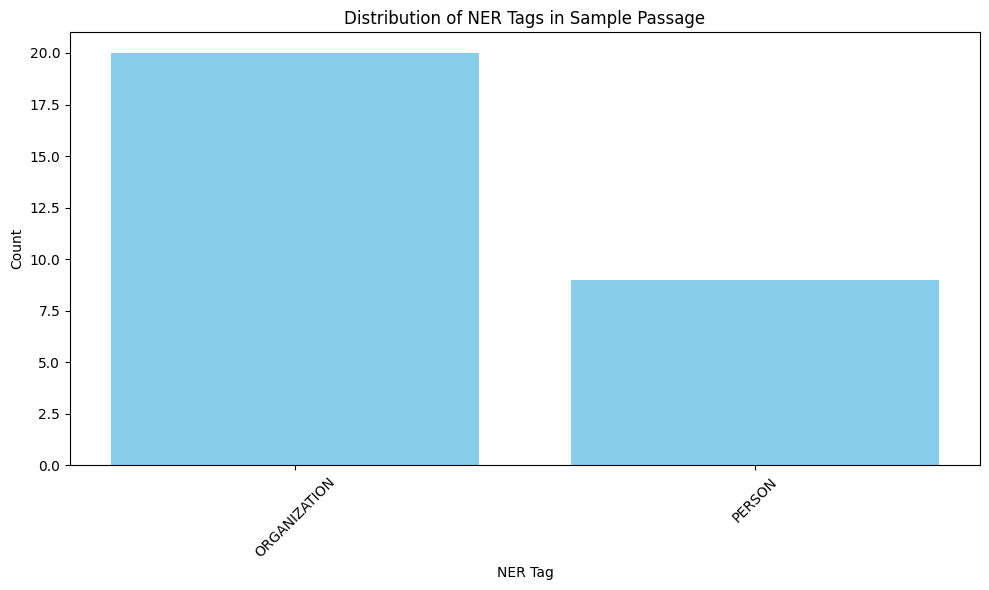


HIGHLIGHTED PASSAGE:

<IEER_DOC type="NEWSWIRE" fileid="" collect_date="" collect_src="" src_lang="" content_lang="" proc_remarks="IEER document translation">
<DOC>
<DOCNO> APW19980314.0391 </DOCNO>
<DOCTYPE> NEWS STORY </DOCTYPE>
<DATE_TIME> 03/14/1998 10:36:00 </DATE_TIME>
<BODY>
<HEADLINE>
Kenyans protest tax hikes
</HEADLINE>
<TEXT>
	   <b_enamex type="LOCATION">NAIROBI<e_enamex>, <b_enamex type="LOCATION">Kenya<e_enamex> (<b_enamex type="ORGANIZATION">AP<e_enamex>) _ <b_numex type="CARDINAL">Thousands<e_numex> of laborers, students and
opposition politicians on <b_timex type="DATE">Saturday<e_timex> protested tax hikes imposed by
their cash-strapped government, which they accused of failing to
provide basic services. Beneath a scorching sun, they sang anti-government songs and
chanted ``<b_enamex type="PERSON">Moi<e_enamex> must go,'' showing their derision for President
<b_enamex type="PERSON">Daniel arap Moi<e_enamex>, <b_enamex type="LOCATION">Kenya<e_enamex>'s ruler for <b_ti

In [6]:
# Visualization of tag distribution
import matplotlib.pyplot as plt
labels, counts = zip(*sorted(label_counts.items()))
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color="skyblue")
plt.xlabel("NER Tag")
plt.ylabel("Count")
plt.title("Distribution of NER Tags in Sample Passage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Highlight coverage of NER tags in text with different colors
from termcolor import colored
def highlight_entities(text, entities):
    for entity_text, label in entities:
        color = "red" if label == "PERSON" else "green" if label == "ORGANIZATION" else "yellow" if label in {"GPE", "LOCATION", "FACILITY", "GSP"} else "cyan"
        text = text.replace(entity_text, colored(entity_text, color))
    return text
highlighted_passage = highlight_entities(passage, entities)
print("\nHIGHLIGHTED PASSAGE:\n")
print(highlighted_passage)

### NER tags in nltk ne_chunk
- PERSON
- ORGANIZATION
- GPE
- LOCATION
- FACILITY
- GSP

### IEER corpus (multiple files for `ne_chunk`)

In [7]:
from nltk.corpus import ieer

# Build a sample passage from multiple IEER files for qualitative inspection
target_tags = {"PERSON", "ORGANIZATION", "GPE", "LOCATION", "FACILITY", "GSP"}
ieer_files = ieer.fileids()

candidates = []
for fid in ieer_files:
    text = ieer.raw(fid)
    sents = sent_tokenize(text)
    current_passage = " ".join(sents[:10]) if len(sents) >= 10 else text

    toks = word_tokenize(current_passage)
    pos = pos_tag(toks)
    tree = ne_chunk(pos, binary=False)
    labels = {ch.label() for ch in tree if hasattr(ch, "label")}
    score = len(labels & target_tags)

    candidates.append({
        "file": fid,
        "passage": current_passage,
        "labels": labels,
        "score": score,
    })

# Keep this for exploration only (not used for metric evaluation)
candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
top_k = candidates[:10]

selected_files = [item["file"] for item in top_k]
passage = " ".join(item["passage"] for item in top_k)

combined_labels = set()
for item in top_k:
    combined_labels.update(item["labels"])

current_file = ", ".join(selected_files)
print("IEER files used for exploration:", selected_files)
print("\nTAGS FOUND:", sorted(combined_labels))
print("MISSING:", sorted(target_tags - combined_labels))
print("\nPASSAGE:\n")
print(passage)

IEER files used for exploration: ['NYT_19980407', 'APW_19980424', 'NYT_19980403', 'APW_19980314', 'APW_19980429', 'NYT_19980315']

TAGS FOUND: ['GPE', 'GSP', 'LOCATION', 'ORGANIZATION', 'PERSON']
MISSING: ['FACILITY']

PASSAGE:

<IEER_DOC type="NEWSWIRE" fileid="" collect_date="" collect_src="" src_lang="" content_lang="" proc_remarks="IEER document translation">
<DOC>
<DOCNO> NYT19980407.0213 </DOCNO>
<DOCTYPE> NEWS STORY </DOCTYPE>
<DATE_TIME> 04/07/1998 17:18:00 </DATE_TIME>
<BODY>
<HEADLINE>
<b_enamex type="PERSON">SUSAN SPICER<e_enamex>, THE QUIET STAR OF <b_enamex type="LOCATION">NEW ORLEANS<e_enamex>
</HEADLINE>
<TEXT>
	   <b_enamex type="LOCATION">NEW ORLEANS<e_enamex> _ In a town famous for its flamboyance, <b_enamex type="PERSON">Susan Spicer<e_enamex>
is the city's stealth chef. Unlike <b_enamex type="PERSON">Emeril Legasse<e_enamex> or <b_enamex type="PERSON">Justin Wilson<e_enamex>,
she speaks softly, has no desire to build a restaurant empire and
serves neither Cajun nor 

In [8]:
# Build real ground truth from IEER annotations (no prediction fallback)
from nltk.tree import Tree

def ieer_tree_to_tokens_iob(node):
    tokens_out = []
    tags_out = []

    for child in node:
        if isinstance(child, Tree):
            label = child.label()
            child_tokens = [str(tok) for tok in child.leaves()]
            for i, tok in enumerate(child_tokens):
                prefix = "B" if i == 0 else "I"
                tokens_out.append(tok)
                tags_out.append(f"{prefix}-{label}")
        else:
            tokens_out.append(str(child))
            tags_out.append("O")

    return tokens_out, tags_out

# Use an evaluation set that is independent of model predictions
eval_file_count = 10
eval_files = ieer.fileids()[:eval_file_count]

all_gt_tokens = []
all_gt_iob = []

for fid in eval_files:
    parsed_docs = ieer.parsed_docs(fid)
    if len(parsed_docs) == 0:
        continue
    doc = parsed_docs[0]
    toks, iob = ieer_tree_to_tokens_iob(doc.text)
    all_gt_tokens.extend(toks)
    all_gt_iob.extend(iob)

# Create the evaluation span from annotated tokens
MAX_TOKENS = 1200
passage_tokens = all_gt_tokens[:MAX_TOKENS]
ground_truth_iob = all_gt_iob[:MAX_TOKENS]
passage = " ".join(passage_tokens)

print(f"Evaluation files used: {eval_files}")
print(f"Ground-truth tokens prepared: {len(ground_truth_iob)}")
print("Using real IEER annotations as ground truth (ground_truth_iob).")

Evaluation files used: ['APW_19980314', 'APW_19980424', 'APW_19980429', 'NYT_19980315', 'NYT_19980403', 'NYT_19980407']
Ground-truth tokens prepared: 1200
Using real IEER annotations as ground truth (ground_truth_iob).


In [9]:
# 2) Run NER + entity-level evaluation (seqeval)
from nltk.chunk import tree2conlltags

try:
    from seqeval.metrics import precision_score, recall_score, f1_score
except ImportError as exc:
    raise ImportError(
        "seqeval is required for entity-level metrics. Install it with: pip install seqeval"
    ) from exc

# Prefer annotated token stream when available to keep strict alignment with ground truth
tokens = list(globals().get("passage_tokens", word_tokenize(passage)))
tagged_tokens = pos_tag(tokens)
ner_tree = ne_chunk(tagged_tokens, binary=False)

# Flatten NLTK tree output to IOB tags
pred_iob_tags = [tag for _, _, tag in tree2conlltags(ner_tree)]

# Small alignment map in case your ground truth uses different entity names
TAG_ALIGNMENT = {
    "B-PERSON": "B-PER",
    "I-PERSON": "I-PER",
    "B-ORGANIZATION": "B-ORG",
    "I-ORGANIZATION": "I-ORG",
    "B-LOCATION": "B-LOC",
    "I-LOCATION": "I-LOC",
    "B-FACILITY": "B-FAC",
    "I-FACILITY": "I-FAC",
    "B-GSP": "B-LOC",
    "I-GSP": "I-LOC",
    "B-GPE": "B-LOC",
    "I-GPE": "I-LOC",
    "O": "O",
}

def align_tag(tag):
    return TAG_ALIGNMENT.get(tag, tag)

pred_iob_tags_aligned = [align_tag(tag) for tag in pred_iob_tags]

# Accept ground truth in one of these formats:
# 1) ground_truth_iob / ground_truth_labels: list[str] IOB tags (preferred)
# 2) ground_truth_tree: nltk.Tree
gt_iob = globals().get("ground_truth_iob")
gt_labels = globals().get("ground_truth_labels")
gt_tree = globals().get("ground_truth_tree")

if gt_iob is not None:
    true_iob_tags = list(gt_iob)
elif gt_labels is not None:
    true_iob_tags = list(gt_labels)
elif gt_tree is not None:
    true_iob_tags = [tag for _, _, tag in tree2conlltags(gt_tree)]
else:
    raise ValueError(
        "Provide ground truth as 'ground_truth_iob'/'ground_truth_labels' (IOB tags) or 'ground_truth_tree' (nltk.Tree)."
    )

true_iob_tags_aligned = [align_tag(tag) for tag in true_iob_tags]

if len(true_iob_tags_aligned) != len(pred_iob_tags_aligned):
    raise ValueError(
        f"Length mismatch: y_true has {len(true_iob_tags_aligned)} tags but y_pred has {len(pred_iob_tags_aligned)} tags."
    )

# seqeval expects a list of sequences
y_true = [true_iob_tags_aligned]
y_pred = [pred_iob_tags_aligned]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nEntity-level NER Evaluation (seqeval)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Entity-level NER Evaluation (seqeval)
Precision: 0.6697
Recall:    0.5573
F1-Score:  0.6083


In [10]:
# 3) Explore different NER tags and extracted entities
entities = []
for chunk in ner_tree:
    if hasattr(chunk, "label"):
        label = chunk.label()
        entity_text = " ".join(word for word, _ in chunk.leaves())
        entities.append((entity_text, label))

label_counts = Counter(label for _, label in entities)

print("\n\nEXTRACTED ENTITIES:")
for entity_text, label in entities:
    print(f"- {entity_text:<35} -> {label}")

print("\nTAGS FOUND (and counts):")
for label, count in sorted(label_counts.items()):
    print(f"- {label}: {count}")



EXTRACTED ENTITIES:
- NAIROBI                             -> GPE
- Kenya                               -> GPE
- AP                                  -> ORGANIZATION
- Daniel                              -> PERSON
- Moi                                 -> PERSON
- Kenya                               -> PERSON
- Kivutha Kibwana                     -> PERSON
- National Convention Assembly        -> ORGANIZATION
- Simeon Nyachae                      -> PERSON
- Kenyans                             -> PERSON
- Moi                                 -> PERSON
- Kenneth Matiba                      -> PERSON
- Moi                                 -> GPE
- International Monetary Fund         -> ORGANIZATION
- Kenya                               -> PERSON
- IMF                                 -> ORGANIZATION
- Kenya                               -> GPE
- Kamukunji Grounds                   -> ORGANIZATION
- Nairobi                             -> GPE
- Kenya                               -> GPE
- John

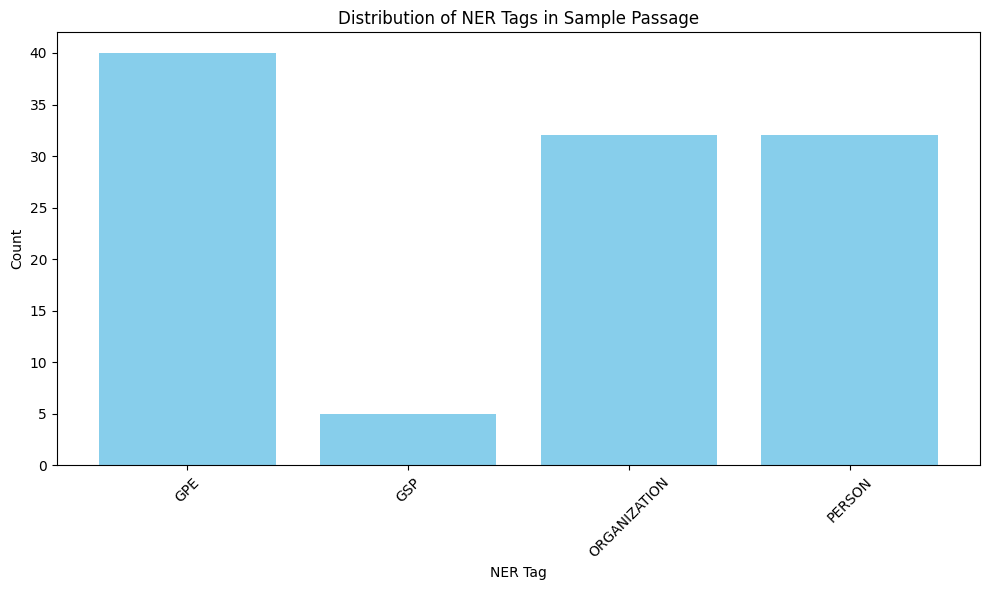


HIGHLIGHTED PASSAGE:

NAIROBI , Kenya ( AP ) _ Thousands of laborers, students and opposition politicians on Saturday protested tax hikes imposed by their cash-strapped government, which they accused of failing to provide basic services. Beneath a scorching sun, they sang anti-government songs and chanted `` Moi must go,'' showing their derision for President Daniel arap Moi , Kenya 's ruler for 20 years . By voice vote, the 5,000 protesters approved a resolution calling for the government to scrap new taxes, convene a convention to write a new Constitution, stop harassing students and street vendors, and halt ethnic violence. If the government doesn't respond to the demands, workers should go on strike April 3 , said Kivutha Kibwana , of the National Convention Assembly , a group of opposition political, church and civic leaders who organized the rally. Although the crowd cheered its support, the assembly's calls for general strikes have failed in the past. Kenyans are most angered b

In [11]:
# Visualization of tag distribution
import matplotlib.pyplot as plt
labels, counts = zip(*sorted(label_counts.items()))
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color="skyblue")
plt.xlabel("NER Tag")
plt.ylabel("Count")
plt.title("Distribution of NER Tags in Sample Passage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Highlight coverage of NER tags in text with different colors
from termcolor import colored
def highlight_entities(text, entities):
    for entity_text, label in entities:
        color = "red" if label == "PERSON" else "green" if label == "ORGANIZATION" else "yellow" if label in {"GPE", "LOCATION", "FACILITY", "GSP"} else "cyan"
        text = text.replace(entity_text, colored(entity_text, color))
    return text
highlighted_passage = highlight_entities(passage, entities)
print("\nHIGHLIGHTED PASSAGE:\n")
print(highlighted_passage)

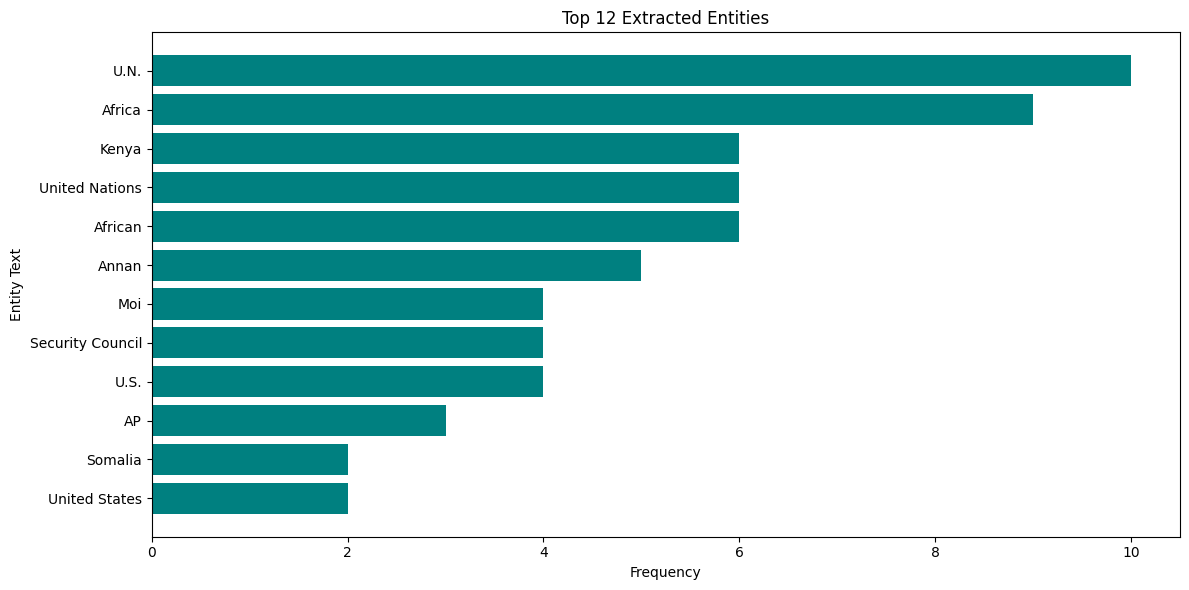

In [12]:
entity_freq = Counter(entity_text for entity_text, _ in entities)

if entity_freq:
    top_n = 12
    top_entities = entity_freq.most_common(top_n)
    names = [name for name, _ in top_entities]
    values = [count for _, count in top_entities]

    plt.figure(figsize=(12, 6))
    plt.barh(names[::-1], values[::-1], color="teal")
    plt.xlabel("Frequency")
    plt.ylabel("Entity Text")
    plt.title(f"Top {min(top_n, len(top_entities))} Extracted Entities")
    plt.tight_layout()
    plt.show()
else:
    print("No entities available to visualize.")

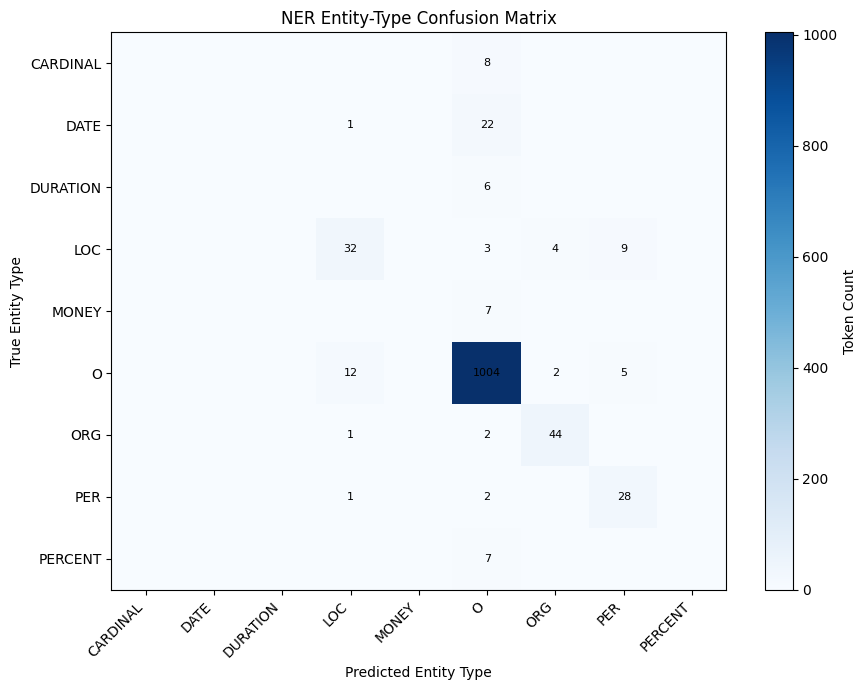

In [13]:
def iob_to_type(tag):
    if tag == "O":
        return "O"
    if "-" in tag:
        return tag.split("-", 1)[1]
    return tag

if "true_iob_tags_aligned" in globals() and "pred_iob_tags_aligned" in globals():
    true_types = [iob_to_type(tag) for tag in true_iob_tags_aligned]
    pred_types = [iob_to_type(tag) for tag in pred_iob_tags_aligned]

    labels = sorted(set(true_types) | set(pred_types))
    label_to_idx = {label: idx for idx, label in enumerate(labels)}

    matrix = [[0 for _ in labels] for _ in labels]
    for t, p in zip(true_types, pred_types):
        matrix[label_to_idx[t]][label_to_idx[p]] += 1

    plt.figure(figsize=(9, 7))
    plt.imshow(matrix, cmap="Blues", aspect="auto")
    plt.colorbar(label="Token Count")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted Entity Type")
    plt.ylabel("True Entity Type")
    plt.title("NER Entity-Type Confusion Matrix")

    for i in range(len(labels)):
        for j in range(len(labels)):
            value = matrix[i][j]
            if value > 0:
                plt.text(j, i, str(value), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("Run the evaluation cell first to generate true/predicted IOB tags.")